**Fraud Detection**

In [ ]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Train Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# loading dataset

df = pd.read_csv("/content/fraud_detection_dataset.csv")

**Data Exploration**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TransactionID  1000 non-null   int64 
 1   Amount         1000 non-null   int64 
 2   Time           1000 non-null   int64 
 3   Location       1000 non-null   object
 4   Merchant       1000 non-null   object
 5   DeviceType     1000 non-null   object
 6   Fraud          1000 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 54.8+ KB


In [ ]:
df

,TransactionID,Amount,Time,Location,Merchant,DeviceType,Fraud
0,1,78325,9,Chennai,Flipkart,Mobile,0
1,2,10337,18,Hyderabad,Paytm,Tablet,0
2,3,53189,19,Chennai,Amazon,Tablet,0
3,4,22970,22,Delhi,Unknown,Tablet,0
4,5,13444,22,Delhi,Unknown,Tablet,0
...,...,...,...,...,...,...,...
995,996,51133,1,Hyderabad,Unknown,Tablet,1
996,997,93582,0,Mumbai,Paytm,Tablet,1
997,998,78029,9,Mumbai,Flipkart,Mobile,0
998,999,68009,9,Delhi,Myntra,Tablet,0


In [ ]:
df.describe()

,TransactionID,Amount,Time,Fraud
count,1000.000000,1000.000000,1000.00000,1000.00000
mean,500.500000,49647.679000,11.85900,0.21600
std,288.819436,28604.260852,7.08995,0.41172
min,1.000000,102.000000,0.00000,0.00000
25%,250.750000,24311.750000,6.00000,0.00000
50%,500.500000,51135.500000,12.00000,0.00000
75%,750.250000,73714.250000,18.00000,0.00000
max,1000.000000,99963.000000,23.00000,1.00000


In [ ]:
df.isnull().sum()

,0
TransactionID,0
Amount,0
Time,0
Location,0
Merchant,0
DeviceType,0
Fraud,0


**Drop Unnecessary Column**

In [ ]:
df.drop("TransactionID", axis=1, inplace=True)

In [ ]:
df

,Amount,Time,Location,Merchant,DeviceType,Fraud
0,78325,9,Chennai,Flipkart,Mobile,0
1,10337,18,Hyderabad,Paytm,Tablet,0
2,53189,19,Chennai,Amazon,Tablet,0
3,22970,22,Delhi,Unknown,Tablet,0
4,13444,22,Delhi,Unknown,Tablet,0
...,...,...,...,...,...,...
995,51133,1,Hyderabad,Unknown,Tablet,1
996,93582,0,Mumbai,Paytm,Tablet,1
997,78029,9,Mumbai,Flipkart,Mobile,0
998,68009,9,Delhi,Myntra,Tablet,0


**Encode Categorical Values**

In [ ]:
# le = LabelEncoder()

# df['Location'] = le.fit_transform(df['Location'])

# df['Merchant'] = le.fit_transform(df['Merchant'])

# df['DeviceType'] = le.fit_transform(df['DeviceType'])

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.head(20)

,Amount,Time,Location,Merchant,DeviceType,Fraud
0,78325,9,1,1,1,0
1,10337,18,3,3,2,0
2,53189,19,1,0,2,0
3,22970,22,2,4,2,0
4,13444,22,2,4,2,0
5,35445,0,0,4,1,1
6,65217,1,3,1,1,1
7,28501,0,0,1,1,0
8,95001,4,2,2,0,0
9,29461,23,3,2,2,0


**Define Features and Target**

In [ ]:
x = df.drop('Fraud', axis=1)

y = df['Fraud']

In [ ]:
y

,Fraud
0,0
1,0
2,0
3,0
4,0
...,...
995,1
996,1
997,0
998,0


**Train - Test Split**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    random_state= 42,
    test_size= 0.2
)

**Logistic Regression Model**

In [ ]:
# we need Standard Scaler to equalize the values for different cols
# we need to standardise values/data for cols when we r using Logistic Regression
from sklearn.preprocessing import StandardScaler

Main Reasons
1. Features are on very different scales

Example:

Time → 0 to 23

Amount → 1000 to 90000

Large differences slow convergence.

In [ ]:
#Scaling our x_train and x_test

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [ ]:
lr_model = LogisticRegression(max_iter= 1000) # increasing iterations

lr_model.fit(x_train, y_train)

y_pred_lr = lr_model.predict(x_test)

In [ ]:
print(y_pred_lr)

[1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0
 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0
 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0]


**Evaluate Logistic Regression**

In [ ]:
print("Logistic Regression Accuracy : ",
      accuracy_score(y_test, y_pred_lr))
print()

print("Classification report : ",
      classification_report(y_test, y_pred_lr))
print()

print("Confusion Matrix : ",
      confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy :  0.85

Classification report :                precision    recall  f1-score   support

           0       0.87      0.95      0.90       149
           1       0.78      0.57      0.66        51

    accuracy                           0.85       200
   macro avg       0.82      0.76      0.78       200
weighted avg       0.84      0.85      0.84       200


Confusion Matrix :  [[141   8]
 [ 22  29]]


**Random Forest**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators = 100,
    class_weight='balanced',
    random_state = 42
)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

In [ ]:
print(y_pred_rf)

[1 1 1 0 1 0 1 0 0 0 0 1 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 1 1
 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0
 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0]


**Evaluate Random Forest**

In [ ]:
print("Random Forest Accuracy : ",
      accuracy_score(y_test, y_pred_rf))
print()

print("Classification Report : ",
      classification_report(y_test, y_pred_rf))
print()

print("Confusion Matrix : ",
      confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy :  1.0

Classification Report :                precision    recall  f1-score   support

           0       1.00      1.00      1.00       149
           1       1.00      1.00      1.00        51

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix :  [[149   0]
 [  0  51]]


**Compare Both Models**

Precision → How many predicted frauds were actually frauds

Recall → How many actual frauds were detected

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression      0.85   0.783784  0.568627  0.659091
1        Random Forest      1.00   1.000000  1.000000  1.000000


**Fraud Distribution**

In [ ]:
print(df['Fraud'].value_counts())

Fraud
0    784
1    216
Name: count, dtype: int64


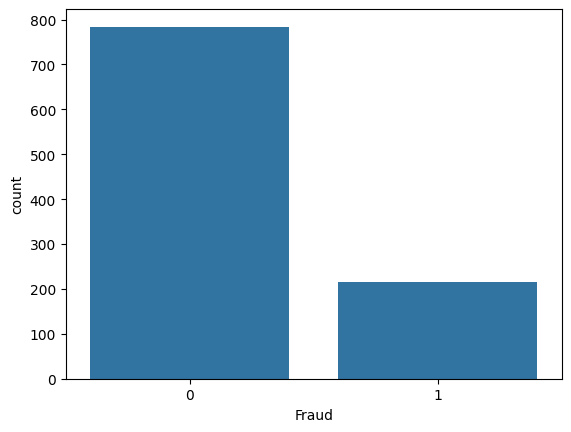

In [ ]:
sns.countplot(x="Fraud", data=df)
plt.show()

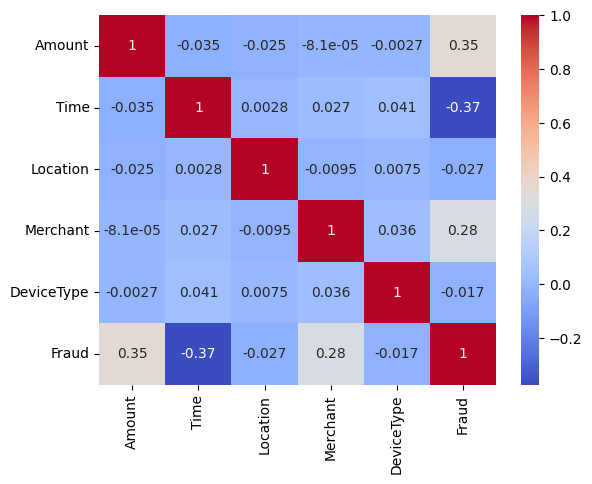

In [ ]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()